# T034 · 基于 RNN 的分子性质预测

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Azat Tagirdzhanov, 2022, [临床生物信息学教席](https://www.ccb.uni-saarland.de/), [NextAID](https://nextaid.cs.uni-saarland.de/) 项目, 萨尔大学


## 本教程的目标

通过 SMILES 字符串表示分子，为将自然语言处理技术应用于广泛的分子相关任务铺平了道路。在本教程中，我们将深入探讨其中一种技术：循环神经网络（RNN）。首先，我们将描述不同的 RNN 架构，然后将其应用于 QM9 数据集上的回归任务。


### _理论_ 部分内容

* 分子作为文本
    * 分词和独热编码
* 循环神经网络（RNN）
    * 标准 RNN
    * 训练 RNN
    * 梯度消失
    * 门控循环单元


### _实践_ 部分内容

* 数据集
* 模型定义
* 训练
* 评估


### 参考文献

#### 系列教程
* __教程 T021__：独热编码
* __教程 T022__：基于配体的筛选：神经网络
* __教程 T033__：分子表示
* __教程 T035__：基于 GNN 的性质预测

#### 理论背景
* Michael Phi, <i>Illustrated Guide to Recurrent Neural Networks</i>, [towardsdatascience](https://towardsdatascience.com/illustrated-guide-to-recurrent-neural-networks-79e5eb8049c9)
* Michael Phi, <i>Illustrated Guide to LSTM's and GRU's: A step by-step explanation</i>, [towardsdatascience](https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21)
* [Modern Recurrent Neural Networks](https://d2l.ai/chapter_recurrent-modern/index.html), <i>D2L.ai: Interactive Deep Learning Book with Multi-Framework Code, Math, and Discussions</i>
* Denny Britz, <i>Recurrent Neural Networks Tutorial</i>, [dennybritz.com](https://dennybritz.com/posts/wildml/recurrent-neural-networks-tutorial-part-1/)
* Andrej Karpathy, <i>The Unreasonable Effectiveness of Recurrent Neural Networks</i>, [Andrej Karpathy blog](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)


In [ ]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 34
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 分子作为文本


要将机器学习应用于分子数据，首先需要将分子转换为可以用作机器学习模型输入的表示。我们已经在 **教程 T033** 中讨论了许多分子表示的方法。在本教程中，我们将使用 SMILES 字符串的文本形式来表示分子。

分子的字符串表示为将自然语言处理（NLP）技术应用于分子数据铺平了道路。近年来，NLP 模型取得了显著进展，其中最著名的是循环神经网络和变压器模型。这些模型被证明擅长捕捉文本语义，当应用于 SMILES 字符串时，可以捕捉分子在其文本表示中的结构。

#### 分词和独热编码
与其他机器学习模型一样，NLP 模型设计用于处理数值输入。我们已经在 **教程 T021** 中讨论了如何将 SMILES 字符串转换为数值形式。在此，我们仅简要介绍关键步骤：
- 要将字符串转换为向量序列，首先将字符串拆分为有意义的块，称为*标记*。例如，对 SMILES 字符串 `C=CCl` 进行分词的一种方法是将其拆分为单个原子和分支符号：`[C, =, C, Cl]`。
- 所有可能的标记构成一个*词汇表*。词汇表通常从数据集中导出，并包含所有数据中最常见标记的固定数量。根据应用的不同，词汇表还可能包含标记词汇表外标记、填充符号等的特殊标记。在我们的示例中，仅限此化合物，词汇表看起来是 `[C, Cl, =]`。将标记替换为它们在词汇表中的索引，我们得到另一种表示 `[0, 2, 0, 1]`。
- 最后，使用独热编码将标记索引序列转换为二进制向量序列：
$$
\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix},~
\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix},~
\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix},~
\begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}.
$$


### 循环神经网络（RNN）


循环神经网络（RNN）专为处理序列数据而设计。为此，它们引入了时间的概念。输入序列的元素一个接一个地被处理，当前时间步的输出作为额外的输入传递到下一个时间步。这是通过引入一种称为*循环连接*的特殊连接类型来实现的（因此得名）。这种架构允许 RNN 积累关于过去的信息，从而捕捉序列中元素之间的依赖关系。

下图说明了 RNN 的基本原理。RNN 单元有一个隐藏状态向量 $h_t$，它在每个时间步 $t$ 被更新，负责聚合关于输入序列先前元素的信息。更新是通过将输入 $x_t$ 与上一个时间步的隐藏状态 $h_{t-1}$ 组合来执行的，该隐藏状态通过循环连接传递到 RNN 单元（图 1，左侧）。

为了更好地可视化 RNN 如何处理数据序列，将网络在时间上展开是有帮助的（图 1，右侧）。RNN 通过在每个时间步复制每个单元并在所有单元之间共享权重和偏置来展开。展开的表示表明 RNN 可以视为具有共享参数的前馈神经网络。


![RNN](images/rnn-unfolded-800.png)

*图 1：*
表示循环神经网络的两种方式：压缩形式（左）和在时间上展开的形式（右）。


隐藏状态计算背后的机制因架构而异。RNN 架构的示例包括标准 RNN（Vanilla RNN）、长短期记忆网络（LSTM）和门控循环单元（GRU）。


#### 标准 RNN（Vanilla RNN）

在标准 RNN 中，隐藏状态根据以下递推关系更新：

$$h_{t} = \tanh( W x_{t} + U h_{t-1} + b),~~~t=1,2,\dots,L.$$

这里 $W$ 和 $U$ 是权重矩阵，$b$ 是偏置向量。初始隐藏状态 $h_0$ 通常设为零向量。模型权重 $W$、$U$ 和 $b$ 在所有时间步之间共享。


#### 训练 RNN
与其他神经网络类似，RNN 使用反向传播算法进行训练。RNN 中使用的一种变体称为*随时间反向传播*（BPTT）。BPTT 将反向传播应用于展开的网络，以计算网络权重的损失函数梯度，同时考虑参数共享。


#### 梯度消失

标准 RNN 容易受到称为*梯度消失*的问题的影响。当网络靠前层的权重梯度在通过网络反向传播时变得非常小时，深度神经网络中就会出现这个问题。这可能导致训练缓慢和性能不佳。在 RNN 中，反向传播应用于展开的网络，而展开的网络往往非常深。此外，展开网络中 RNN 单元的所有副本共享相同的权重，这可能导致梯度以指数速度减小。有关梯度消失问题的更多详细信息，请参阅博客文章：[随时间反向传播和梯度消失](https://dennybritz.com/posts/wildml/recurrent-neural-networks-tutorial-part-3/)。


#### 门控循环单元（GRU）
门控循环单元（GRU）是一种更先进的循环网络架构，旨在解决梯度消失问题。除了隐藏状态向量之外，GRU 还引入了所谓的*更新门*和*重置门*。这两个向量帮助模型决定哪些信息应该向前传递。它们可以被训练为保留从很久以前的信息，而不会随时间流逝而冲掉，或者去除与预测无关的信息。


##### 重置门

该门由 GRU 单元用于决定要忘记多少过去的信息。它的计算公式如下：

$$r_t = \sigma(W_{r} x_t + U_{r} h_{t-1} + b_r).$$

输入向量 $x_t$ 与权重矩阵 $W_r$ 相乘。来自前一个时间步的隐藏状态 $h_{t-1}$ 也被输入到单元中，并与它的权重矩阵 $U_r$ 相乘。两个结果与偏置向量 $b_r$ 相加，然后通过 sigmoid 激活函数将输出限制在 0 到 1 之间。

##### 更新门

更新门使用类似的公式计算：

$$z_t = \sigma(W_{z} x_t + U_{z} h_{t-1} + b_z),$$

但它有自己的权重 $W_z$、$U_z$、$b_z$，并且服务于不同的目的。如下所示，更新门帮助 GRU 单元决定有多少过去的信息应该传递到未来的步骤。

##### 隐藏状态候选

候选隐藏状态存储来自过去的相关信息。它的计算方式如下：

$$\hat{h}_t = \tanh(W_{h} x_t + U_{h}(r_t \odot h_{t-1}) + b_h),$$

其中 $\odot$ 是[逐元素乘积](https://en.wikipedia.org/wiki/Hadamard_product_(matrices))，$r_t$ 是上面介绍的重置门向量。这个公式看起来类似于简单 RNN 单元中隐藏状态的更新方式，但这里前一个时间步的隐藏状态 $h_{t-1}$ 与重置门向量 $r_t$ 相乘。由于 sigmoid 激活，$r_t$ 的分量取值在 0 和 1 之间。通过使用重置门，模型可以学习哪些信息不相关并应被丢弃。例如，如果 $r_t$ 的第 $i$ 个分量接近 0，则 $h_{t-1}$ 的第 $i$ 个分量中包含的记忆将在候选向量中被丢弃。

##### 隐藏状态更新

最后，隐藏状态更新为 $h_{t-1}$ 和隐藏状态候选的混合：

$$h_t =   z_t \odot h_{t-1} + (1-z_t) \odot  \hat{h}_t. $$

这里，更新门向量 $z_t$ 控制从候选向量 $\hat{h}_t$ 中收集多少信息，以及从上一步 $h_{t-1}$ 中保留多少信息。


## 实践


在实践部分，我们将把循环神经网络应用于一个回归任务。


In [1]:
import os
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset

In [2]:
# 如果可用则使用 cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 设置随机种子
_ = torch.manual_seed(42)

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 数据集


在本教程中，我们使用来自 [MoleculeNet](https://arxiv.org/abs/1703.00564) 论文的 [QM9](https://pytorch-geometric.readthedocs.io/en/2.2.0/modules/datasets.html#torch_geometric.datasets.QM9) 数据集。该数据集包含大约 130,000 个分子及其量子化学性质。


In [4]:
# 加载数据集
df = pd.read_csv(os.path.join(DATA, "qm9.csv.gz"), compression="gzip")
df.head()

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,smiles
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772,C
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802,N
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171,O
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724,C#C
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028,C#N


在本教程中，我们将构建一个模型，根据上表中 `smiles` 列提供的分子字符串表示来预测其中一个性质——偶极矩 `mu`。


#### 预处理


首先，定义我们将用于数据预处理的类和辅助函数。


In [5]:
class SmilesTokenizer(object):
    """
    一个基于正则表达式的简单分词器，改编自 deepchem 的 smiles_tokenizer 包。
    分词所用的 SMILES 正则表达式模式由 Schwaller et. al., ACS Cent. Sci 5 (2019) 设计。
    """

    def __init__(self):
        self.regex_pattern = (
            r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\."
            r"|=|#|-|\+|\\|\/|:|~|@|\?|>>?|\*|\$|\%[0-9]{2}|[0-9])"
        )
        self.regex = re.compile(self.regex_pattern)

    def tokenize(self, smiles):
        """
        Tokenizes SMILES string.

        Parameters
        ----------
        smiles : str
            Input SMILES string.

        Returns
        -------
        List[str]
            A list of tokens.
        """
        tokens = [token for token in self.regex.findall(smiles)]
        return tokens

In [6]:
def build_vocab(smiles_list, tokenizer, max_vocab_size):
    """
    从 SMILES 字符串列表中构建由 N=max_vocab_size 个最常见标记组成的词汇表。

    Parameters
    ----------
    smiles_list : List[str]
        SMILES 字符串列表。
    tokenizer : SmilesTokenizer
    max_vocab_size : int
        词汇表的最大大小。

    Returns
    -------
    Dict[str, int]
        A dictionary that defines mapping of a token to its index in the vocabulary.
    """
    tokenized_smiles = [tokenizer.tokenize(s) for s in smiles_list]
    token_counter = Counter(c for s in tokenized_smiles for c in s)
    tokens = [token for token, _ in token_counter.most_common(max_vocab_size)]
    vocab = {token: idx for idx, token in enumerate(tokens)}
    return vocab


def smiles_to_ohe(smiles, tokenizer, vocab):
    """
    Transforms SMILES string to one-hot encoding representation.

    Parameters
    ----------
    smiles : str
        Input SMILES string.
    tokenizer : SmilesTokenizer
    vocab : Dict[str, int]
        A dictionary that defines mapping of a token to its index in the vocabulary.

    Returns
    -------
    Tensor
        A pytorch Tensor with shape (n_tokens, vocab_size), where n_tokens is the
        length of tokenized input string, vocab_size is the number of tokens in
        the vocabulary
    """
    unknown_token_id = len(vocab) - 1
    token_ids = [vocab.get(token, unknown_token_id) for token in tokenizer.tokenize(smiles)]
    ohe = torch.eye(len(vocab))[token_ids]
    return ohe

让我们通过一个简单的示例来看这些函数如何工作。这里，我们将使用与理论部分相同的 SMILES 字符串。


In [7]:
tokenizer = SmilesTokenizer()

smiles = "C=CCl"
print("SMILES string:\n\t", smiles)
print("Tokens:\n\t", ", ".join(tokenizer.tokenize(smiles)))
vocab = build_vocab([smiles], tokenizer, 3)
print("Vocab:\n\t", vocab)
print("OHE:\n", np.array(smiles_to_ohe(smiles, tokenizer, vocab)).T)

SMILES string:
	 C=CCl
Tokens:
	 C, =, C, Cl
Vocab:
	 {'C': 0, '=': 1, 'Cl': 2}
OHE:
 [[1. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


现在，我们将这些预处理步骤应用于数据。为了减少运行时间，我们将仅使用整个 QM9 数据集的一个随机子集。数据集被分为训练集、验证集和测试集。我们仅基于训练集构建词汇表并定义目标的变换。


In [8]:
sample_size = 50000
n_train = 40000
n_test = n_val = 5000

# 获取样本
df = df.sample(n=sample_size, axis=0, random_state=42)

# 从数据框中选择列
smiles = df["smiles"].tolist()
y = df["mu"].to_numpy()

# 使用训练数据构建词汇表
max_vocab_size = 30
vocab = build_vocab(smiles[:n_train], tokenizer, max_vocab_size)
vocab_size = len(vocab)

# 将 SMILES 转换为独热编码 encoded tensors and apply padding
X = pad_sequence(
    sequences=[smiles_to_ohe(smi, tokenizer, vocab) for smi in smiles],
    batch_first=True,
    padding_value=0,
)

# normalize the target using the training data
train_mean = y[:n_train].mean()
train_std = y[:n_train].std()
y = (y - train_mean) / train_std

# build dataset
data = TensorDataset(X, torch.Tensor(y))

# define loaders
ids_train = np.arange(n_train)
ids_val = np.arange(n_val) + n_train
ids_test = np.arange(n_test) + n_train + n_val
train_loader = DataLoader(
    Subset(data, ids_train),
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)
val_loader = DataLoader(
    Subset(data, ids_val), batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(42)
)
test_loader = DataLoader(
    Subset(data, ids_test),
    batch_size=1,
    shuffle=False,
    generator=torch.Generator().manual_seed(42),
)

### 模型

在本教程中，我们比较两种循环网络。它们都包含一个循环层，后接一个全连接层，将最后一个时间步的隐藏状态转换为一维输出。在 `RNNRegressionModel` 中，我们使用标准 RNN 架构，而在 `GRURegressionModel` 中，我们使用更先进的 GRU 架构。


In [9]:
class RNNRegressionModel(nn.Module):
    """带有一个循环层的标准 RNN"""

    def __init__(self, input_size, hidden_size=32, num_layers=1):
        """
        Vanilla RNN

        Parameters
        ----------
        input_size : int
            输入向量中期望的特征数量
        hidden_size : int
            隐藏状态的特征数量

        """
        super(RNNRegressionModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, hn = self.rnn(x, h0)
        out = out[:, -1]
        out = self.dropout(out)
        out = self.fc(out)
        return out


class GRURegressionModel(nn.Module):
    """GRU network with one recurrent layer"""

    def __init__(self, input_size, hidden_size=32, num_layers=1):
        """
        GRU network

        Parameters
        ----------
        input_size : int
            输入向量中期望的特征数量
        hidden_size : int
            隐藏状态的特征数量

        """
        super(GRURegressionModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, hn = self.gru(x, h0)
        out = out[:, -1]
        out = self.dropout(out)
        out = self.fc(out)
        return out

### 训练


In [10]:
class ModelTrainer(object):
    """为模型提供训练和验证基础设施，并跟踪训练和验证指标的类。"""

    def __init__(self, model, lr, name=None, clip_gradients=False):
        """
        Initialization.

        Parameters
        ----------
        model : nn.Module
            模型
        lr : float
            学习率 for one training step

        """
        self.model = model
        self.lr = lr
        self.criterion = torch.nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), self.lr)
        self.clip_gradients = clip_gradients
        self.model.to(device)

        self.train_loss = []
        self.batch_loss = []
        self.val_loss = []

    def _train_epoch(self, loader):
        self.model.train()
        epoch_loss = 0
        batch_losses = []
        for i, (X_batch, y_batch) in enumerate(loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            self.optimizer.zero_grad()
            y_pred = self.model(X_batch)
            loss = self.criterion(y_pred, y_batch.unsqueeze(1))
            loss.backward()

            if self.clip_gradients:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1, norm_type=2)

            self.optimizer.step()
            epoch_loss += loss.item()
            batch_losses.append(loss.item())

        return epoch_loss / len(loader), batch_losses

    def _eval_epoch(self, loader):
        self.model.eval()
        val_loss = 0
        predictions = []
        targets = []
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = self.model(X_batch)
                loss = self.criterion(y_pred, y_batch.unsqueeze(1))
                val_loss += loss.item()
                predictions.append(y_pred.detach().numpy())
                targets.append(y_batch.unsqueeze(1).detach().numpy())

        predictions = np.concatenate(predictions).flatten()
        targets = np.concatenate(targets).flatten()
        return val_loss / len(loader), predictions, targets

    def train(self, train_loader, val_loader, n_epochs, print_every=10):
        """
        Train the model

        Parameters
        ----------
        train_loader :
            a dataloader with training data
        val_loader :
            a dataloader with training data
        n_epochs :
            number of epochs to train for
        """
        for e in range(n_epochs):
            train_loss, train_loss_batches = self._train_epoch(train_loader)
            val_loss, _, _ = self._eval_epoch(test_loader)
            self.batch_loss += train_loss_batches
            self.train_loss.append(train_loss)
            self.val_loss.append(val_loss)
            if e % print_every == 0:
                print(f"Epoch {e+0:03} | train_loss: {train_loss:.5f} | val_loss: {val_loss:.5f}")

    def validate(self, val_loader):
        """
        Validate the model

        Parameters
        ----------
        val_loader :
            a dataloader with training data

        Returns
        -------
        Tuple[list, list, list]
            Loss, y_predicted, y_target for each datapoint in val_loader.
        """
        loss, y_pred, y_targ = self._eval_epoch(val_loader)
        return loss, y_pred, y_targ

现在我们定义模型并训练它们 50 个 epoch。两种模型的隐藏状态维度相同。


In [11]:
model_rnn = ModelTrainer(
    model=RNNRegressionModel(vocab_size, hidden_size=32),
    lr=1e-3,
)

In [12]:
model_rnn.train(train_loader, val_loader, 51)

Epoch 000 | train_loss: 1.00060 | val_loss: 0.93796
Epoch 010 | train_loss: 0.63185 | val_loss: 0.56341
Epoch 020 | train_loss: 0.53801 | val_loss: 0.49376
Epoch 030 | train_loss: 0.50546 | val_loss: 0.45505
Epoch 040 | train_loss: 0.48365 | val_loss: 0.44333
Epoch 050 | train_loss: 0.46981 | val_loss: 0.43694


In [13]:
model_gru = ModelTrainer(
    model=GRURegressionModel(vocab_size, hidden_size=32),
    lr=1e-3,
)

In [14]:
model_gru.train(train_loader, val_loader, 51)

Epoch 000 | train_loss: 0.73387 | val_loss: 0.53829
Epoch 010 | train_loss: 0.43030 | val_loss: 0.40386
Epoch 020 | train_loss: 0.37359 | val_loss: 0.36704
Epoch 030 | train_loss: 0.33639 | val_loss: 0.34342
Epoch 040 | train_loss: 0.31038 | val_loss: 0.32925
Epoch 050 | train_loss: 0.29032 | val_loss: 0.31914


### 评估


首先，我们比较模型在训练期间的表现。我们绘制了每个 epoch 在训练集和验证集上的损失。正如我们所见，GRU 模型训练更快，并且与标准 RNN 相比具有更好的整体性能。


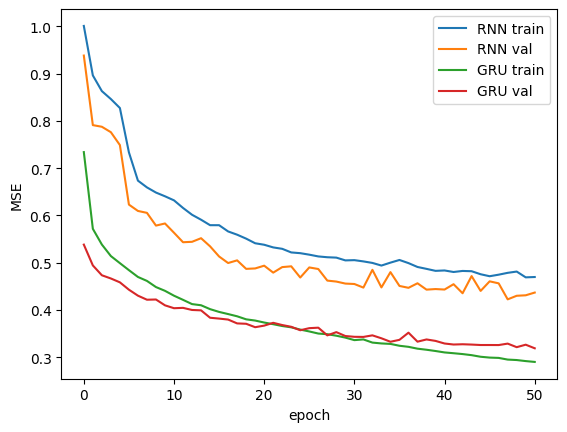

In [15]:
_ = plt.plot(model_rnn.train_loss, label=f"RNN train")
_ = plt.plot(model_rnn.val_loss, label=f"RNN val")
_ = plt.plot(model_gru.train_loss, label=f"GRU train")
_ = plt.plot(model_gru.val_loss, label=f"GRU val")
_ = plt.xlabel("epoch")
_ = plt.ylabel("MSE")
_ = plt.legend()

为了进一步评估模型的性能，我们计算测试集上的损失，并将预测值与真实值进行视觉比较。从图中可以看出，与 GRU 模型相比，标准 RNN 倾向于产生更偏斜的预测。


RNN test loss: 0.437
GRU test loss: 0.319


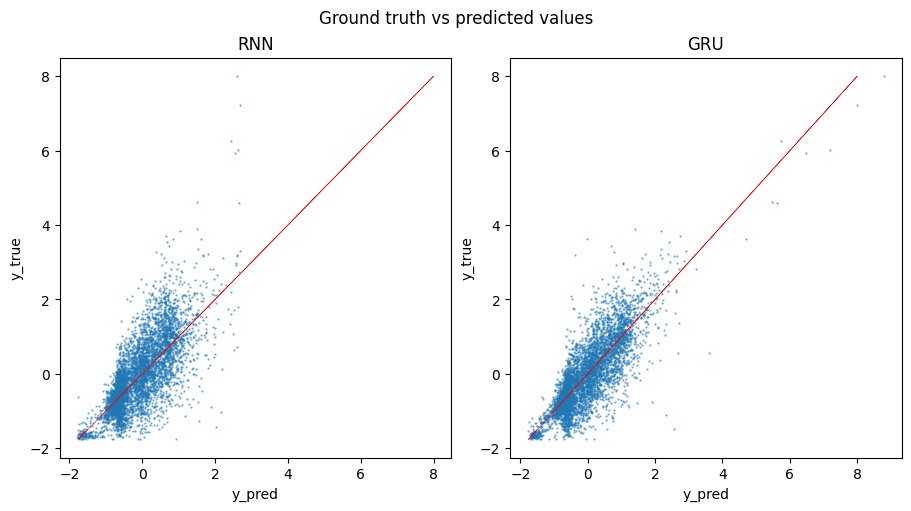

In [16]:
f, axarr = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)

f.suptitle("Ground truth vs predicted values")

loss, y_pred, y_targ = model_rnn.validate(test_loader)
print(f"RNN test loss: {loss:.3f}")

_ = axarr[0].scatter(y_pred, y_targ, alpha=0.5, s=0.5)
_ = axarr[0].plot(y_targ, y_targ, lw=0.4, c="r")
_ = axarr[0].set_title("RNN")

loss, y_pred, y_targ = model_gru.validate(test_loader)
print(f"GRU test loss: {loss:.3f}")

_ = axarr[1].scatter(y_pred, y_targ, alpha=0.5, s=0.5)
_ = axarr[1].plot(y_targ, y_targ, lw=0.4, c="r")
_ = axarr[1].set_title("GRU")

for ax in axarr:
    _ = ax.set_xlabel("y_pred")
    _ = ax.set_ylabel("y_true")

## 讨论

基于自然语言处理的模型被证明是广泛应用于分子相关任务的强大工具。在本教程中，我们介绍了循环神经网络架构的基础知识，并演示了它们在 QM9 数据集上的回归任务中的应用。我们学习了如何预处理 SMILES 字符串、使用 PyTorch 构建模型，以及训练模型预测分子的偶极矩。


## 测验

1. 循环神经网络在训练过程中会遇到什么问题？
2. 在本教程中，我们使用了基于正则表达式的分词器。还可以使用哪些其他分词方法？
3. 为什么门控循环单元架构更适合捕捉长期依赖关系？
